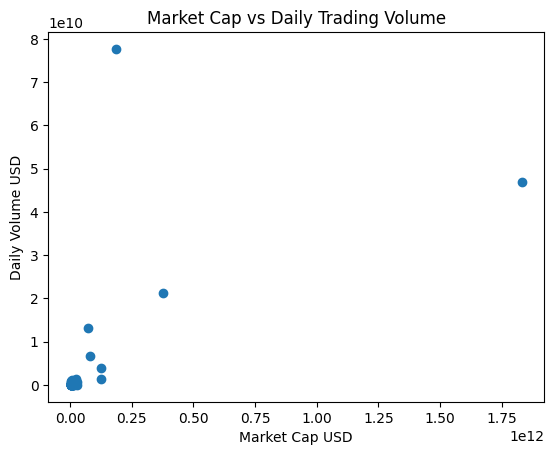

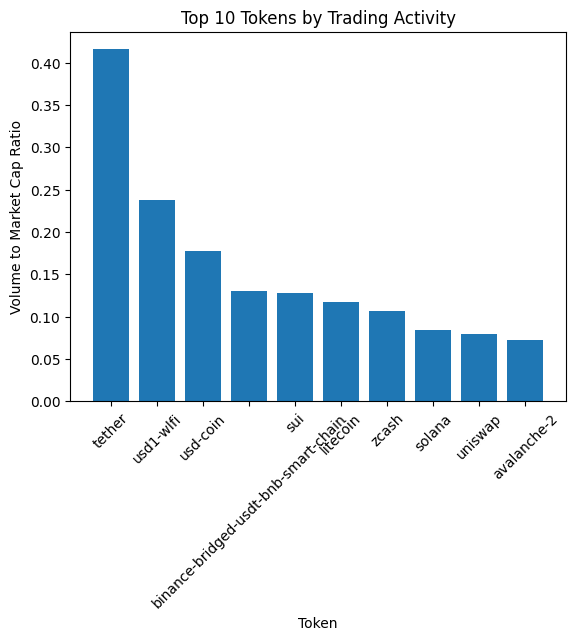

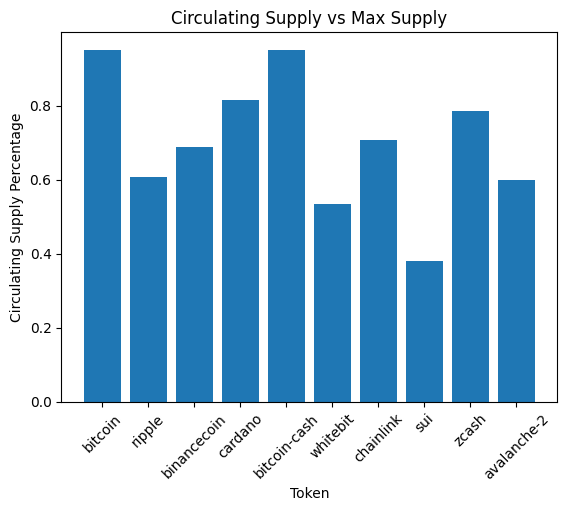

In [1]:
# ----------------------------------------
# Step 1: Import libraries
# ----------------------------------------
import requests
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------------------
# Step 2: Call CoinGecko API
# Get top 50 cryptocurrencies by market cap
# ----------------------------------------
url = "https://api.coingecko.com/api/v3/coins/markets"

params = {
    "vs_currency": "usd",
    "order": "market_cap_desc",
    "per_page": 50,
    "page": 1,
    "sparkline": False
}

response = requests.get(url, params=params)
data = response.json()

# ----------------------------------------
# Step 3: Load data into DataFrame
# ----------------------------------------
df = pd.DataFrame(data)

# ----------------------------------------
# Step 4: Select and clean important columns
# Focus on tokenomics metrics
# ----------------------------------------
df = df[
    [
        "id",
        "symbol",
        "current_price",
        "market_cap",
        "total_volume",
        "circulating_supply",
        "total_supply",
        "max_supply"
    ]
]

df.columns = [
    "token",
    "symbol",
    "price_usd",
    "market_cap",
    "daily_volume",
    "circulating_supply",
    "total_supply",
    "max_supply"
]

# ----------------------------------------
# Step 5: Feature engineering
# Create simple tokenomics insights
# ----------------------------------------
df["volume_to_marketcap"] = df["daily_volume"] / df["market_cap"]
df["circulating_supply_pct"] = df["circulating_supply"] / df["max_supply"]

# Handle missing and infinite values
df = df.replace([float("inf"), -float("inf")], pd.NA)

# ----------------------------------------
# Step 6: Visualization 1
# Market cap vs daily volume
# Shows liquidity differences
# ----------------------------------------
plt.figure()
plt.scatter(df["market_cap"], df["daily_volume"])
plt.xlabel("Market Cap USD")
plt.ylabel("Daily Volume USD")
plt.title("Market Cap vs Daily Trading Volume")
plt.show()

# ----------------------------------------
# Step 7: Visualization 2
# Volume to market cap ratio
# Highlights high trading activity tokens
# ----------------------------------------
top_volume_ratio = df.sort_values("volume_to_marketcap", ascending=False).head(10)

plt.figure()
plt.bar(top_volume_ratio["token"], top_volume_ratio["volume_to_marketcap"])
plt.xlabel("Token")
plt.ylabel("Volume to Market Cap Ratio")
plt.title("Top 10 Tokens by Trading Activity")
plt.xticks(rotation=45)
plt.show()

# ----------------------------------------
# Step 8: Visualization 3
# Circulating supply percentage
# Shows token inflation characteristics
# ----------------------------------------
supply_df = df.dropna(subset=["circulating_supply_pct"]).head(10)

plt.figure()
plt.bar(supply_df["token"], supply_df["circulating_supply_pct"])
plt.xlabel("Token")
plt.ylabel("Circulating Supply Percentage")
plt.title("Circulating Supply vs Max Supply")
plt.xticks(rotation=45)
plt.show()
